In [1]:
import os, math, random, gc, shutil, sys
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

In [2]:
DATASET_DIR  = '/kaggle/input/datasets/almiraraisa/aptos-2019-augmented'

device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
NUM_CLASSES  = len(CLASS_NAMES)
BATCH_SIZE   = 32
NUM_EPOCHS   = 100
LR           = 1e-4
WEIGHT_DECAY = 1e-5
CKPT_DIR     = '/kaggle/working/'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device: {device}")

Device: cuda


In [3]:
def set_seed(seed=30):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

In [4]:
class AptosDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_col = 'id_code' if 'id_code' in self.df.columns else self.df.columns[0]
        fname = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img = Image.open(self.image_dir / fname).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['diagnosis']), dtype=torch.long)

In [5]:
base_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
train_tfm = base_tfm   # no augmentation
val_tfm   = base_tfm

train_df = pd.read_csv(f'{DATASET_DIR}/train_split.csv')
val_df   = pd.read_csv(f'{DATASET_DIR}/val_split.csv')
test_df  = pd.read_csv(f'{DATASET_DIR}/test_split.csv')

class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float),
                                len(sample_weights), replacement=True)
train_loader = DataLoader(AptosDataset(train_df, f'{DATASET_DIR}/images', train_tfm),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(AptosDataset(val_df,   f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(AptosDataset(test_df,  f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

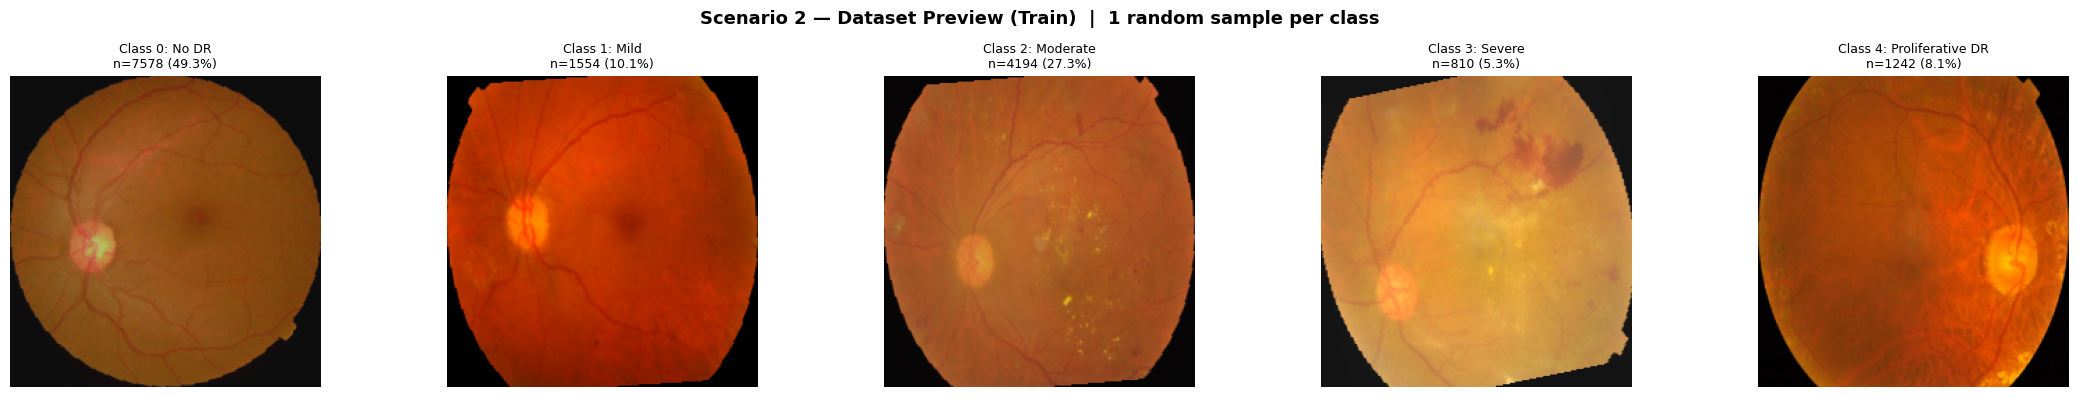


 Dataset Statistics
  Train: 15378 | Val: 549 | Test: 550
  Class distribution (train):
  [0] No DR               : 7578 ( 49.3%)  ██████████████
  [1] Mild                : 1554 ( 10.1%)  ███
  [2] Moderate            : 4194 ( 27.3%)  ████████
  [3] Severe              :  810 (  5.3%)  █
  [4] Proliferative DR    : 1242 (  8.1%)  ██


In [6]:
def preview_dataset(df, image_dir, split_name="Train"):
    image_dir = Path(image_dir)
    img_col   = 'id_code' if 'id_code' in df.columns else df.columns[0]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(f"Scenario 2 — Dataset Preview ({split_name})  |  1 random sample per class",
                 fontsize=13, fontweight='bold')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        subset = df[df['diagnosis'] == cls_idx]
        row    = subset.sample(1, random_state=42).iloc[0]
        fname  = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img    = Image.open(image_dir / fname).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {cls_name}\nn={len(subset)} ({100*len(subset)/len(df):.1f}%)",
            fontsize=9)
        axes[cls_idx].axis('off')
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("\n Dataset Statistics")
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print("  Class distribution (train):")
    for i, name in enumerate(CLASS_NAMES):
        n = (train_df['diagnosis'] == i).sum()
        bar = '█' * int(30 * n / len(train_df))
        print(f"  [{i}] {name:<20s}: {n:4d} ({100*n/len(train_df):5.1f}%)  {bar}")

preview_dataset(train_df, f'{DATASET_DIR}/images')

In [7]:
def analyse_results(results_list, scenario_title, loss_label="Loss", teacher_accs=None):
    seeds      = [r['seed'] for r in results_list]
    all_losses = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks   = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs   = np.array([r['history']['val_acc']    for r in results_list])
    all_mses   = np.array([r['history']['val_mse']    for r in results_list])
    all_rmses  = np.array([r['history']['val_rmse']   for r in results_list])
    epochs     = np.arange(1, all_losses.shape[1] + 1)
    best_res   = max(results_list, key=lambda x: x['qwk'])
    colors     = plt.cm.tab10.colors

    # Aggregate CMs
    cms = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
           for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    seed_accs = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100
                 for r in results_list]
    mean_acc  = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk  = np.mean([r['qwk'] for r in results_list])
    std_qwk   = np.std([r['qwk']  for r in results_list])

    # Final-epoch MSE/RMSE per seed (last epoch value)
    seed_mses  = [r['history']['val_mse'][-1]  for r in results_list]
    seed_rmses = [r['history']['val_rmse'][-1] for r in results_list]
    mean_mse   = np.mean(seed_mses);  std_mse  = np.std(seed_mses)
    mean_rmse  = np.mean(seed_rmses); std_rmse = np.std(seed_rmses)

    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm_avg[i, j] > 0:
                misclass.append((cm_avg[i, j], i, j))
    misclass.sort(reverse=True)

    report = classification_report(best_res['labels'], best_res['preds'],
                                   target_names=CLASS_NAMES, output_dict=True)

    CKPT_SAFE = scenario_title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')

    # =========================================================================
    # FIGURE 1 — Overview Dashboard  (3 rows × 4 cols)
    # =========================================================================
    fig1 = plt.figure(figsize=(24, 16))
    fig1.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                  fontsize=16, fontweight='bold', y=0.99)
    gs1 = gridspec.GridSpec(3, 4, figure=fig1, hspace=0.42, wspace=0.30)

    # ── R0C0: Val Accuracy Boxplot ────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[0, 0])
    bp = ax.boxplot([seed_accs], patch_artist=True, widths=0.4,
                    medianprops=dict(color='red', lw=2))
    bp['boxes'][0].set_facecolor('#aec6e8')
    ax.scatter([1] * len(seed_accs), seed_accs, color='black', s=40, zorder=5)
    ax.set_xticks([1]); ax.set_xticklabels(['Student'])
    ax.set_title(f"Val Accuracy Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    ax.text(1, mean_acc, f"μ={mean_acc:.2f}%\nσ={std_acc:.2f}%",
            ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    # ── R0C1: Teacher vs Student bar OR QWK boxplot ───────────────────────────
    ax = fig1.add_subplot(gs1[0, 1])
    if teacher_accs:
        names  = [f"Teacher {i+1}" for i in range(len(teacher_accs))] + ['Student']
        values = list(teacher_accs) + [mean_acc]
        bar_colors = ['#4878CF'] * len(teacher_accs) + ['#F8A60B']
        bars = ax.bar(range(len(names)), values, color=bar_colors, width=0.5,
                      edgecolor='white', lw=1.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
        ax.set_ylim(min(values) - 5, 100)
        ax.set_title("Teacher vs Student Accuracy", fontsize=11, fontweight='bold')
        ax.set_ylabel("Accuracy (%)")
    else:
        seed_qwks = [r['qwk'] for r in results_list]
        bp2 = ax.boxplot([seed_qwks], patch_artist=True, widths=0.4,
                         medianprops=dict(color='red', lw=2))
        bp2['boxes'][0].set_facecolor('#b8d4a8')
        ax.scatter([1] * len(seed_qwks), seed_qwks, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(f"Val QWK Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Quadratic Weighted Kappa")
        ax.text(1, mean_qwk, f"μ={mean_qwk:.4f}\nσ={std_qwk:.4f}",
                ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # ── R0C2: Validation Accuracy curves (mean ± std band) ───────────────────
    ax = fig1.add_subplot(gs1[0, 2])
    mean_a = all_accs.mean(0) * 100; std_a = all_accs.std(0) * 100
    ax.plot(epochs, mean_a, color='#1f77b4', lw=2.2, label='Mean')
    ax.fill_between(epochs, mean_a - std_a, mean_a + std_a,
                    alpha=0.25, color='#1f77b4', label='±1 std')
    ax.set_title("Validation Accuracy Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # ── R0C3: Training Loss ───────────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[0, 3])
    mean_l = all_losses.mean(0); std_l = all_losses.std(0)
    ax.plot(epochs, mean_l, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, mean_l - std_l, mean_l + std_l, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss Value (Normalized)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # ── R1C0: Individual run validation curves ────────────────────────────────
    ax = fig1.add_subplot(gs1[1, 0])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a * 100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Run {i+1}")
    ax.plot(epochs, mean_a, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Run Validation Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    # ── R1C1: Val MSE curves (mean ± std) ────────────────────────────────────
    ax = fig1.add_subplot(gs1[1, 1])
    mean_mse_curve = all_mses.mean(0); std_mse_curve = all_mses.std(0)
    ax.plot(epochs, mean_mse_curve, color='tomato', lw=2.0, label='Mean MSE')
    ax.fill_between(epochs, mean_mse_curve - std_mse_curve, mean_mse_curve + std_mse_curve,
                    alpha=0.20, color='tomato', label='±1 std')
    ax.set_title("Validation MSE Over Training", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # ── R1C2: Val RMSE curves (mean ± std) ───────────────────────────────────
    ax = fig1.add_subplot(gs1[1, 2])
    mean_rmse_curve = all_rmses.mean(0); std_rmse_curve = all_rmses.std(0)
    ax.plot(epochs, mean_rmse_curve, color='darkorange', lw=2.0, label='Mean RMSE')
    ax.fill_between(epochs, mean_rmse_curve - std_rmse_curve, mean_rmse_curve + std_rmse_curve,
                    alpha=0.20, color='darkorange', label='±1 std')
    ax.set_title("Validation RMSE Over Training", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("RMSE")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # ── R1C3: QWK / Loss ratio ────────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[1, 3])
    ratio = all_qwks.mean(0) / (all_losses.mean(0) + 1e-8)
    ax.plot(epochs, ratio, color='purple', lw=1.8)
    ax.set_title("QWK / Loss Ratio Over Training", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("QWK / Loss Ratio")
    ax.grid(True, ls='--', alpha=0.5)

    # ── R2C0: Per-class accuracy bar ──────────────────────────────────────────
    ax = fig1.add_subplot(gs1[2, 0])
    bar_colors_cls = ['#d4edda' if a >= 0.7 else ('#fff3cd' if a >= 0.5 else '#f8d7da')
                      for a in per_cls_acc]
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc * 100, color=bar_colors_cls,
                  edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy\n(from Averaged CM)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # ── R2C1: CM std deviation ────────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[2, 1])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix\nStandard Deviation", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}",
                    ha='center', va='center', fontsize=7.5, color='black')

    # ── R2C2: Average CM raw counts ───────────────────────────────────────────
    ax = fig1.add_subplot(gs1[2, 2])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Raw Counts)", fontsize=11, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}",
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    # ── R2C3: Per-class F1 bar ────────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[2, 3])
    f1_scores = [report[cls]['f1-score'] for cls in CLASS_NAMES]
    f1_colors = ['#d4edda' if f >= 0.7 else ('#fff3cd' if f >= 0.5 else '#f8d7da')
                 for f in f1_scores]
    f1_bars = ax.bar(range(NUM_CLASSES), [f * 100 for f in f1_scores],
                     color=f1_colors, edgecolor='grey', lw=0.8)
    for bar, val in zip(f1_bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 Score\n(Best Seed)", fontsize=11, fontweight='bold')
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.axhline(70, color='green', ls=':', lw=1.2, alpha=0.6)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    fig1.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # FIGURE 2 — Detailed CM Analysis + Performance Summary
    # =========================================================================
    fig2 = plt.figure(figsize=(20, 20))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.55])

    # ── Avg CM raw ────────────────────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[0, 0])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Raw Counts)", fontsize=12, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}",
                    ha='center', va='center', fontsize=9,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    # ── Avg CM normalized ─────────────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[0, 1])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}",
                    ha='center', va='center', fontsize=8.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    # ── CM std deviation ──────────────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[1, 0])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix Standard Deviation", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}",
                    ha='center', va='center', fontsize=8.5, color='black')

    # ── Best-run CM ───────────────────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[1, 1])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    best_acc = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=12, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}",
                    ha='center', va='center', fontsize=9,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    # ── Performance Summary Text Panel ────────────────────────────────────────
    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')

    lines = []
    lines.append("=" * 85)
    lines.append(f"  PERFORMANCE SUMMARY — {scenario_title}")
    lines.append("=" * 85)
    lines.append(f"  Seeds trained              : {seeds}")
    lines.append(f"  Val Accuracy  (mean ± std) : {mean_acc:.2f}%  ±  {std_acc:.2f}%"
                 f"  [range: {min(seed_accs):.2f}% – {max(seed_accs):.2f}%]")
    lines.append(f"  Val QWK       (mean ± std) : {mean_qwk:.4f}  ±  {std_qwk:.4f}"
                 f"  [range: {min(r['qwk'] for r in results_list):.4f} – "
                 f"{max(r['qwk'] for r in results_list):.4f}]")
    lines.append(f"  Val MSE  (final, mean±std) : {mean_mse:.4f}  ±  {std_mse:.4f}"
                 f"  [range: {min(seed_mses):.4f} – {max(seed_mses):.4f}]")
    lines.append(f"  Val RMSE (final, mean±std) : {mean_rmse:.4f}  ±  {std_rmse:.4f}"
                 f"  [range: {min(seed_rmses):.4f} – {max(seed_rmses):.4f}]")
    lines.append(f"  Best seed                  : Seed {best_res['seed']}"
                 f"  (QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%,"
                 f"  MSE={best_res['history']['val_mse'][-1]:.4f},"
                 f"  RMSE={best_res['history']['val_rmse'][-1]:.4f})")
    lines.append(f"  Final train loss (mean)    : {all_losses[:, -1].mean():.4f}"
                 f"  ±  {all_losses[:, -1].std():.4f}")
    lines.append(f"  Peak QWK epoch  (mean)     : "
                 f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}")
    lines.append("")
    lines.append("  Per-class Performance (best seed):")
    lines.append(f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
                 f"{'F1-Score':>9s}  {'Support':>7s}  {'Status'}")
    lines.append("  " + "-" * 75)
    for cls in CLASS_NAMES:
        d    = report[cls]
        flag = '✓ Good' if d['f1-score'] >= 0.7 else ('~ OK' if d['f1-score'] >= 0.5 else '✗ Poor')
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                     f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}  {flag}")
    lines.append("  " + "-" * 75)
    lines.append(f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
                 f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}")
    lines.append(f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
                 f"{report['macro avg']['recall']:>9.3f}  "
                 f"{report['macro avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append(f"  {'Weighted Avg F1':<20s}  {report['weighted avg']['precision']:>9.3f}  "
                 f"{report['weighted avg']['recall']:>9.3f}  "
                 f"{report['weighted avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append("")
    lines.append("  Top-5 Most Common Misclassifications (averaged across seeds):")
    for rank, (count, true_c, pred_c) in enumerate(misclass[:5], 1):
        pct = count / cm_avg.sum(axis=1)[true_c] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[true_c]:<20s} → "
                     f"Predicted={CLASS_NAMES[pred_c]:<20s}"
                     f"  (avg count={count:.1f}, {pct:.1f}% of true class)")
    lines.append("")
    lines.append("  Class Performance Range (per-class accuracy from averaged CM):")
    cls_accs_sorted = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines.append(f"    Best  : {cls_accs_sorted[0][1]}  ({cls_accs_sorted[0][0]*100:.1f}%)")
    lines.append(f"    Worst : {cls_accs_sorted[-1][1]}  ({cls_accs_sorted[-1][0]*100:.1f}%)")
    lines.append(f"    Class Performance Range: "
                 f"{cls_accs_sorted[-1][0]*100:.1f}% – {cls_accs_sorted[0][0]*100:.1f}%"
                 f"  (gap = {(cls_accs_sorted[0][0]-cls_accs_sorted[-1][0])*100:.1f}pp)")
    lines.append("=" * 85)

    summary_text = '\n'.join(lines)
    ax_txt.text(0.01, 0.99, summary_text, transform=ax_txt.transAxes,
                fontsize=7.8, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.9, edgecolor='#dee2e6'))

    fig2.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\n'.join(lines))

In [8]:
TEMPERATURE = 5.0
ALPHA       = 0.7

# models
def get_resnet50_teacher():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def get_mobilenet_student():
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

In [9]:
def _compute_mse_rmse(labels, preds):
    """Compute MSE and RMSE between integer label arrays."""
    labels_arr = np.array(labels, dtype=np.float32)
    preds_arr  = np.array(preds,  dtype=np.float32)
    mse  = float(np.mean((labels_arr - preds_arr) ** 2))
    rmse = float(np.sqrt(mse))
    return mse, rmse

def train_teacher_ce(model, seed):
    name      = f"ResNet-50_Seed{seed}"
    save_path = f'{CKPT_DIR}/s2_teacher_resnet50_seed{seed}.pth'

    model  = model.to(device)
    opt    = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else torch.amp.GradScaler('cpu')

    best_qwk = -1.0
    best_acc = 0.0
    history  = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                 'val_mse': [], 'val_rmse': []}

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            opt.zero_grad()
            with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                loss = F.cross_entropy(model(imgs), labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(model(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())

        qwk  = float(cohen_kappa_score(v_labels, v_preds, weights='quadratic'))
        acc  = float(np.mean(np.array(v_labels) == np.array(v_preds)))
        mse, rmse = _compute_mse_rmse(v_labels, v_preds)

        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mse'].append(mse)
        history['val_rmse'].append(rmse)

        print(f"  [Teacher] Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk; best_acc = acc
            torch.save({'epoch': epoch+1, 'model_state_dict': model.state_dict(),
                        'qwk': best_qwk, 'history': history}, save_path)

    model.load_state_dict(
        torch.load(save_path, map_location=device, weights_only=False)['model_state_dict'])
    model.eval()
    print(f"\n best val QWK={best_qwk:.4f}")
    return model, best_acc

In [10]:
def train_student_s2(student, teacher_model, seed, alpha=ALPHA, temperature=TEMPERATURE):
    save_path = f'{CKPT_DIR}/s2_seed{seed}_best.pth'
    student   = student.to(device)

    teacher_ref = teacher_model.to(device).eval()
    for p in teacher_ref.parameters(): p.requires_grad_(False)

    opt    = optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda')

    best_qwk = -1.0
    history  = {'train_loss': [], 'val_qwk': [], 'val_acc': [],
                 'val_mse': [], 'val_rmse': []}
    best_preds, best_labels = [], []

    for epoch in range(NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                s_l = student(imgs); t_l = teacher_ref(imgs)
                ce  = F.cross_entropy(s_l, labels)
                kl  = F.kl_div(F.log_softmax(s_l / temperature, dim=1),
                               F.softmax(t_l.detach() / temperature, dim=1),
                               reduction='batchmean') * (temperature ** 2)
                loss = (1 - alpha) * ce + alpha * kl
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss); sched.step()

        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(student(imgs.to(device)).argmax(dim=1).cpu().numpy())
                v_labels.extend(labels.numpy())

        qwk  = float(cohen_kappa_score(v_labels, v_preds, weights='quadratic'))
        acc  = float(np.mean(np.array(v_labels) == np.array(v_preds)))
        mse, rmse = _compute_mse_rmse(v_labels, v_preds)

        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mse'].append(mse)
        history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | Acc: {acc*100:.2f}% | "
              f"QWK: {qwk:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            torch.save({'epoch': epoch+1, 'model_state_dict': student.state_dict(),
                        'qwk': best_qwk, 'history': history}, save_path)

    print(f"\n best QWK={best_qwk:.4f})")
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed}

In [11]:
# training loop
results_s2          = []
teacher_accuracies  = []

for seed in [33, 81, 5]:
    set_seed(seed)
    print(f"\n  SCENARIO 2 — Single-Teacher KD (ResNet-50 CE)  |  Seed {seed}\n")

    print(f"Training Teacher for Seed {seed}")
    current_teacher, t_acc = train_teacher_ce(get_resnet50_teacher(), seed)
    teacher_accuracies.append(t_acc * 100)

    print(f"Training Student for Seed {seed}")
    res = train_student_s2(get_mobilenet_student(), current_teacher, seed)
    results_s2.append(res)

    cleanup_memory()


  SCENARIO 2 — Single-Teacher KD (ResNet-50 CE)  |  Seed 33

Training Teacher for Seed 33
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


  [Teacher] Epoch 001 | Loss: 0.4580 | Acc: 76.50% | QWK: 0.8462 | MSE: 0.5392 | RMSE: 0.7343
  [Teacher] Epoch 002 | Loss: 0.1551 | Acc: 81.79% | QWK: 0.8562 | MSE: 0.4353 | RMSE: 0.6598
  [Teacher] Epoch 003 | Loss: 0.0953 | Acc: 79.23% | QWK: 0.8599 | MSE: 0.4463 | RMSE: 0.6680
  [Teacher] Epoch 004 | Loss: 0.0658 | Acc: 77.60% | QWK: 0.8519 | MSE: 0.4718 | RMSE: 0.6869
  [Teacher] Epoch 005 | Loss: 0.0614 | Acc: 80.33% | QWK: 0.8476 | MSE: 0.4754 | RMSE: 0.6895
  [Teacher] Epoch 006 | Loss: 0.0584 | Acc: 81.42% | QWK: 0.8701 | MSE: 0.4135 | RMSE: 0.6430
  [Teacher] Epoch 007 | Loss: 0.0516 | Acc: 79.60% | QWK: 0.8697 | MSE: 0.4281 | RMSE: 0.6543
  [Teacher] Epoch 008 | Loss: 0.0503 | Acc: 80.87% | QWK: 0.8650 | MSE: 0.4390 | RMSE: 0.6626
  [Teacher] Epoch 009 | Loss: 0.0283 | Acc: 82.51% | QWK: 0.8860 | MSE: 0.3607 | RMSE: 0.6005
  [Teacher] Epoch 010 | Loss: 0.0438 | Acc: 81.06% | QWK: 0.8664 | MSE: 0.4171 | RMSE: 0.6458
  [Teacher] Epoch 011 | Loss: 0.0365 | Acc: 79.78% | QWK: 0.

100%|██████████| 9.83M/9.83M [00:00<00:00, 121MB/s]


  Epoch 001 | Loss: 6.9360 | Acc: 74.13% | QWK: 0.8496 | MSE: 0.5373 | RMSE: 0.7330
  Epoch 002 | Loss: 3.2484 | Acc: 76.68% | QWK: 0.8580 | MSE: 0.5046 | RMSE: 0.7103
  Epoch 003 | Loss: 2.0924 | Acc: 77.23% | QWK: 0.8540 | MSE: 0.4718 | RMSE: 0.6869
  Epoch 004 | Loss: 1.5717 | Acc: 77.60% | QWK: 0.8498 | MSE: 0.4954 | RMSE: 0.7039
  Epoch 005 | Loss: 1.2719 | Acc: 79.78% | QWK: 0.8707 | MSE: 0.4299 | RMSE: 0.6556
  Epoch 006 | Loss: 1.1241 | Acc: 79.78% | QWK: 0.8675 | MSE: 0.4189 | RMSE: 0.6473
  Epoch 007 | Loss: 0.9719 | Acc: 79.23% | QWK: 0.8575 | MSE: 0.4590 | RMSE: 0.6775
  Epoch 008 | Loss: 0.9004 | Acc: 81.06% | QWK: 0.8670 | MSE: 0.4153 | RMSE: 0.6444
  Epoch 009 | Loss: 0.7680 | Acc: 79.78% | QWK: 0.8501 | MSE: 0.4645 | RMSE: 0.6815
  Epoch 010 | Loss: 0.7089 | Acc: 80.51% | QWK: 0.8716 | MSE: 0.4189 | RMSE: 0.6473
  Epoch 011 | Loss: 0.6792 | Acc: 79.78% | QWK: 0.8557 | MSE: 0.4663 | RMSE: 0.6829
  Epoch 012 | Loss: 0.6314 | Acc: 79.78% | QWK: 0.8600 | MSE: 0.4444 | RMSE:

/tmp/ipykernel_55/176686262.py:219: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0, 1, 0.97])


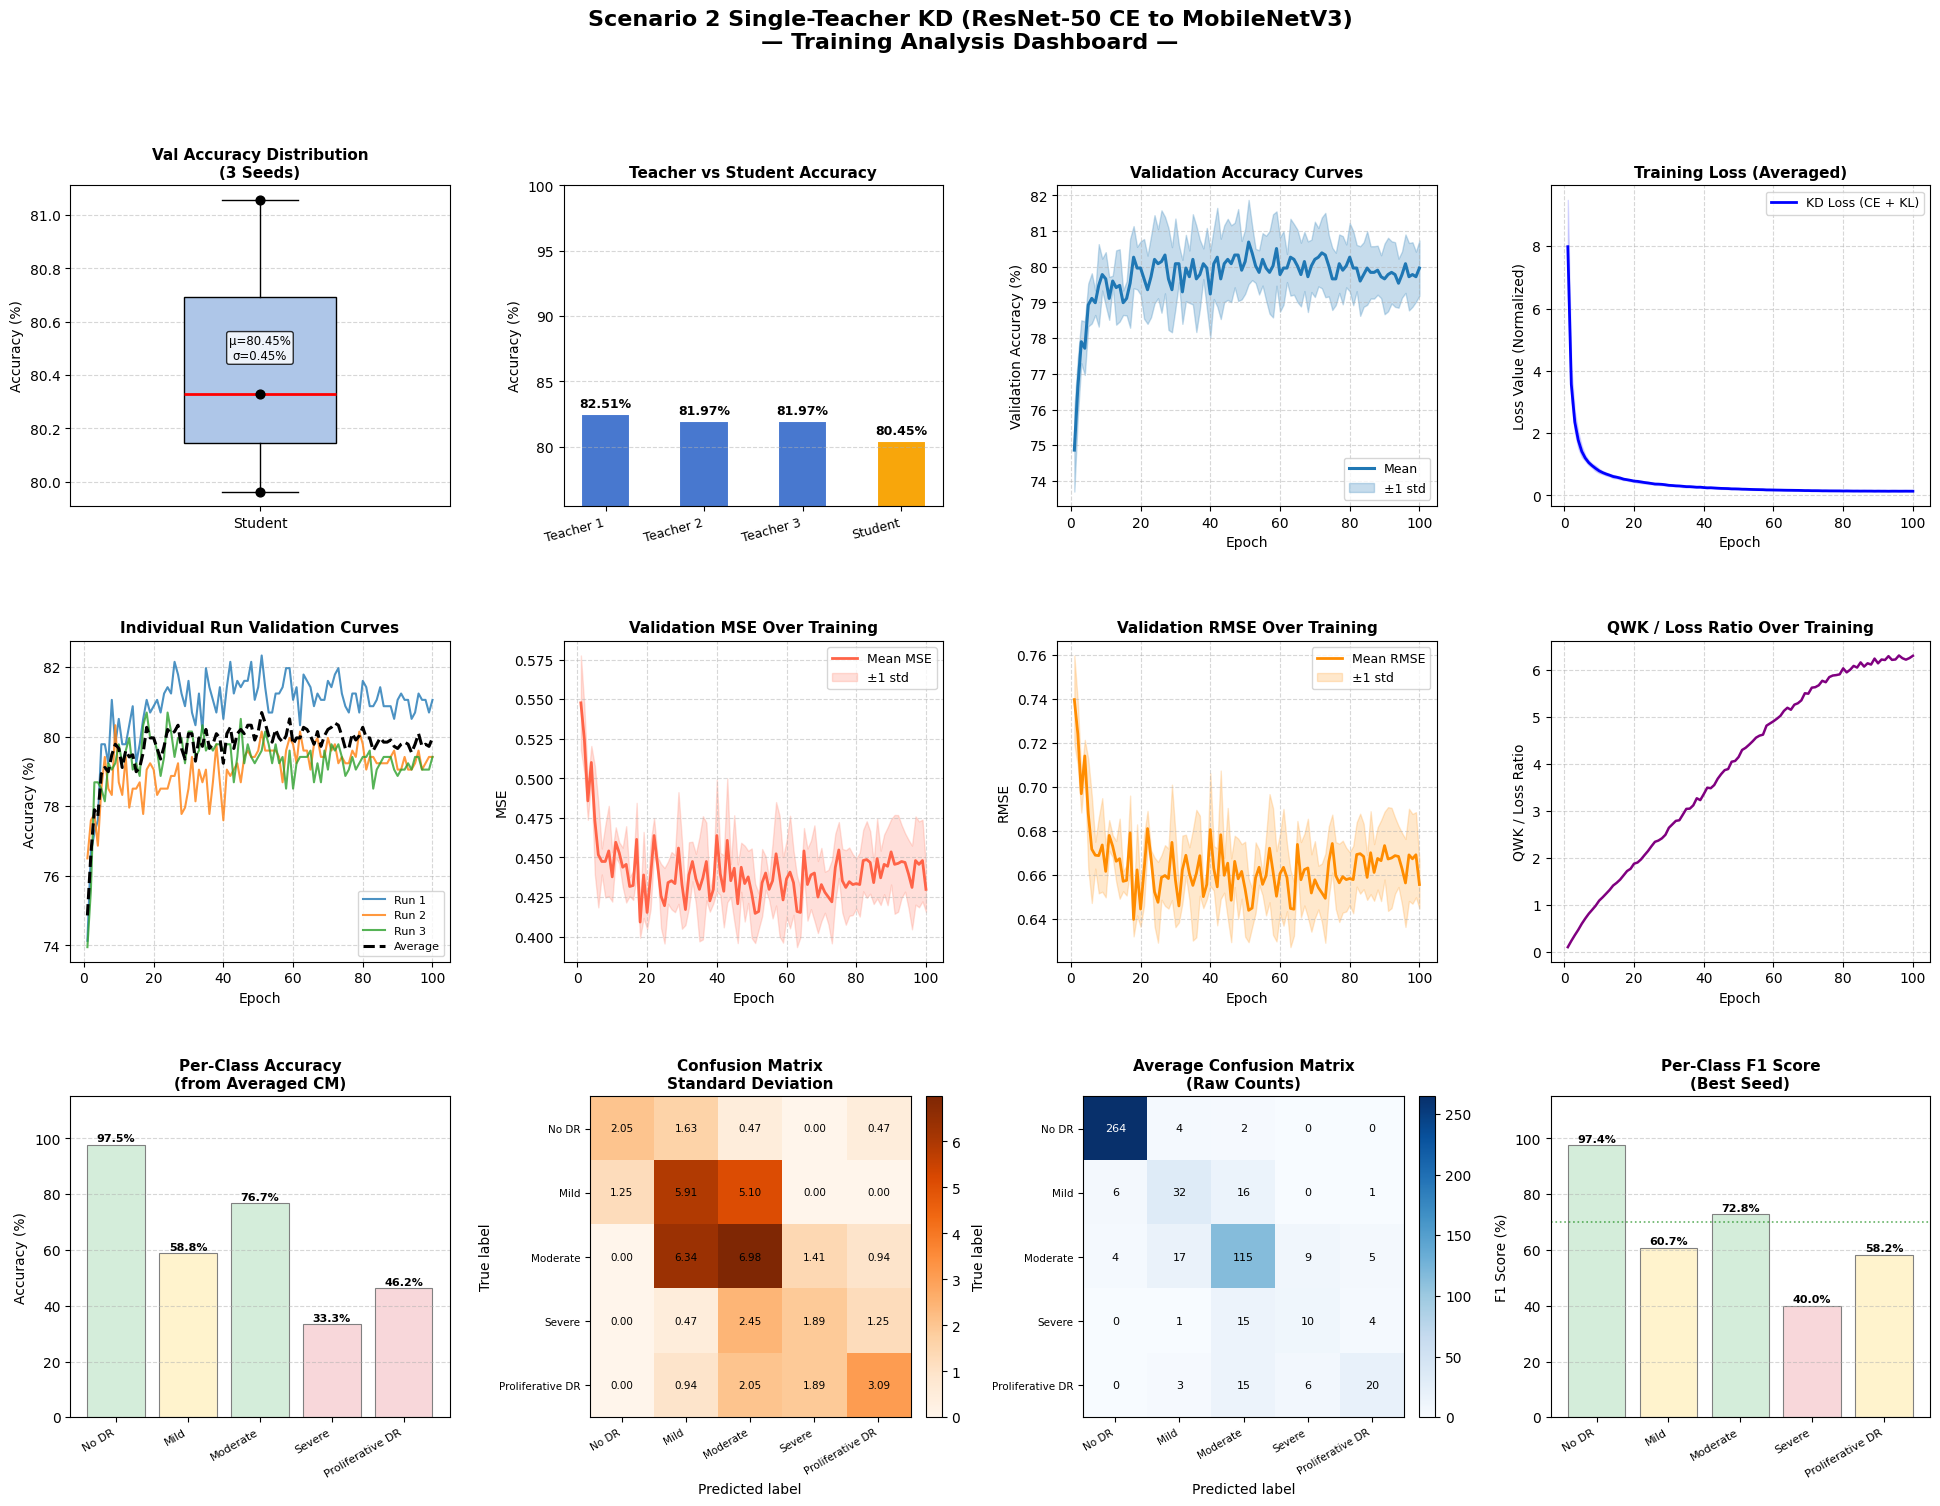

/tmp/ipykernel_55/176686262.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout(rect=[0, 0, 1, 0.97])


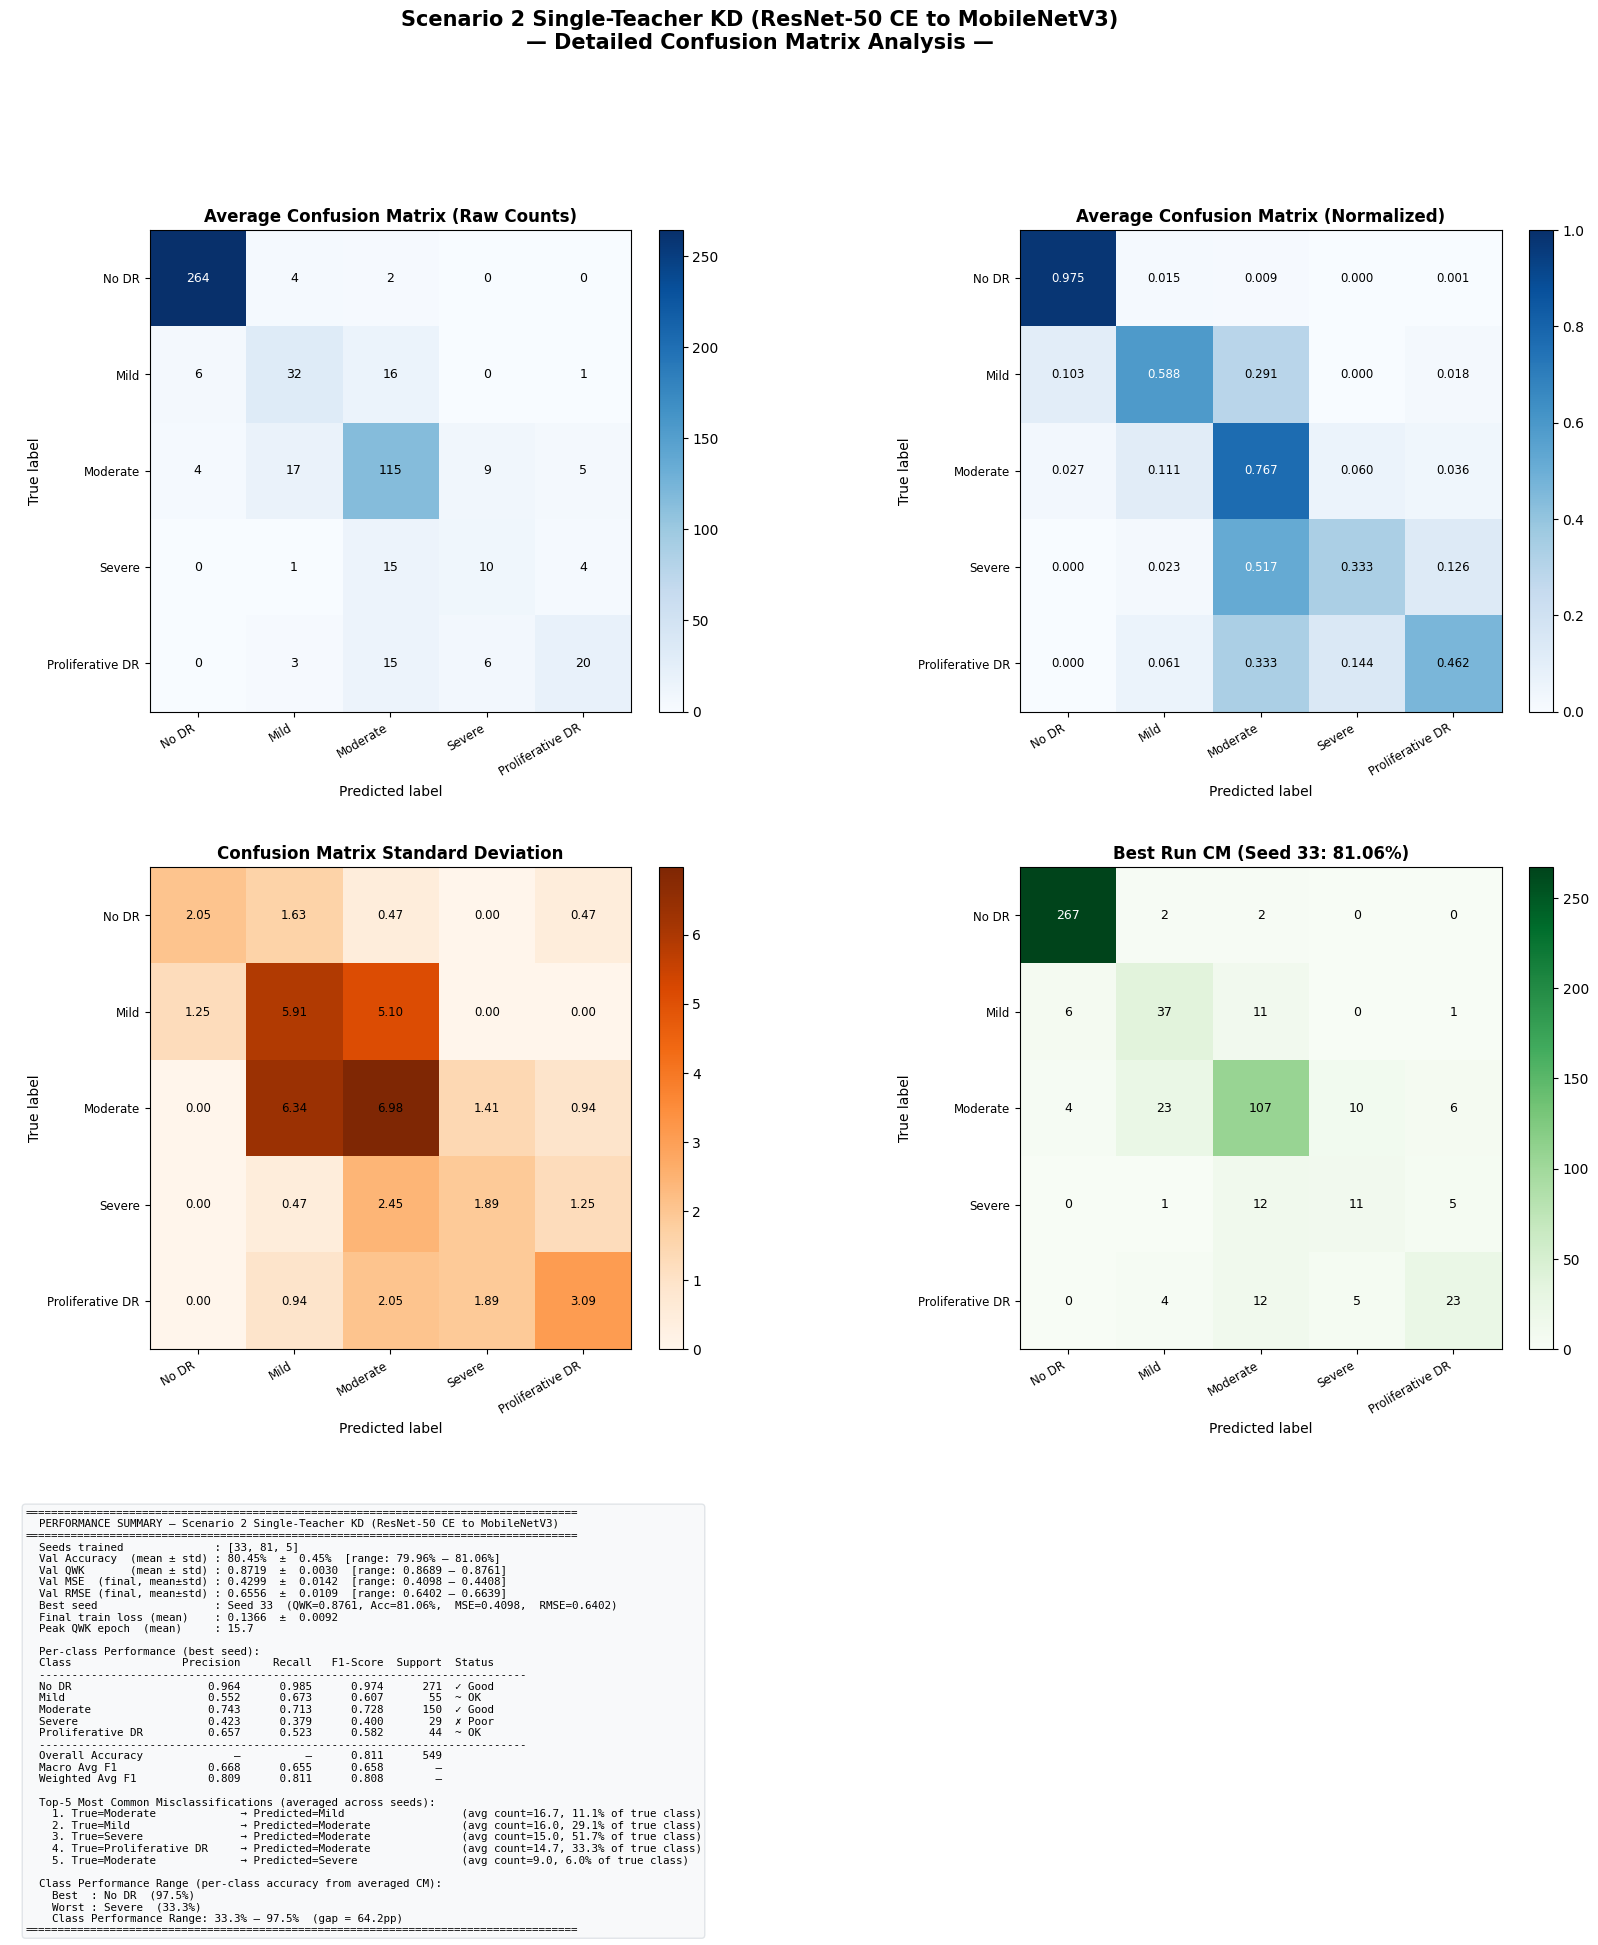

  PERFORMANCE SUMMARY — Scenario 2 Single-Teacher KD (ResNet-50 CE to MobileNetV3)
  Seeds trained              : [33, 81, 5]
  Val Accuracy  (mean ± std) : 80.45%  ±  0.45%  [range: 79.96% – 81.06%]
  Val QWK       (mean ± std) : 0.8719  ±  0.0030  [range: 0.8689 – 0.8761]
  Val MSE  (final, mean±std) : 0.4299  ±  0.0142  [range: 0.4098 – 0.4408]
  Val RMSE (final, mean±std) : 0.6556  ±  0.0109  [range: 0.6402 – 0.6639]
  Best seed                  : Seed 33  (QWK=0.8761, Acc=81.06%,  MSE=0.4098,  RMSE=0.6402)
  Final train loss (mean)    : 0.1366  ±  0.0092
  Peak QWK epoch  (mean)     : 15.7

  Per-class Performance (best seed):
  Class                 Precision     Recall   F1-Score  Support  Status
  ---------------------------------------------------------------------------
  No DR                     0.964      0.985      0.974      271  ✓ Good
  Mild                      0.552      0.673      0.607       55  ~ OK
  Moderate                  0.743      0.713      0.728      150 

In [12]:
analyse_results(results_s2,
                "Scenario 2 Single-Teacher KD (ResNet-50 CE to MobileNetV3)",
                loss_label="KD Loss (CE + KL)",
                teacher_accs=teacher_accuracies)